> ### 📘 Annotated learning edition
> This notebook has been marked up for self-study. **Before every code cell** you'll find a "🔎 Cell explained" box describing *what it does and why it matters* in plain English, and **inside every code cell** each line has a comment explaining it. Read the box first, then read the code with its comments. The actual working code is unchanged, so you can still run everything top-to-bottom.


# 4-Hour Google Colab Hands-on Tutorial
## Supervised Learning Classification Project: Customer Churn Prediction

### Project Theme
You are working as a junior machine learning engineer for a telecom company.

Your task is to build a **supervised machine learning classification model** that predicts whether a customer will **churn** or **not churn** based on customer profile, usage, billing, and support-related features.

This notebook is designed for a **4-hour instructor-led hands-on session**.

## What Students Will Learn
By the end of this tutorial, learners will be able to:

1. Explain supervised learning and classification in simple terms.
2. Understand binary classification using a business example.
3. Generate and load a realistic customer churn dataset.
4. Perform exploratory data analysis for classification.
5. Handle numerical and categorical features.
6. Build preprocessing pipelines using `ColumnTransformer` and `Pipeline`.
7. Train classification models:
   - Dummy Classifier
   - Logistic Regression
   - Decision Tree Classifier
   - Random Forest Classifier
8. Evaluate classification models using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Confusion Matrix
   - ROC-AUC
9. Perform cross-validation and hyperparameter tuning.
10. Save the final model and predict churn for a new customer.

## 4-Hour Tutorial Agenda

| Time | Module | Focus |
|---|---|---|
| 0:00 - 0:25 | Module 1 | Introduction to supervised learning and classification |
| 0:25 - 0:55 | Module 2 | Problem statement and dataset creation |
| 0:55 - 1:35 | Module 3 | Exploratory Data Analysis for classification |
| 1:35 - 2:10 | Module 4 | Data preprocessing and train-test split |
| 2:10 - 2:55 | Module 5 | Model building: baseline, logistic regression, tree models |
| 2:55 - 3:25 | Module 6 | Model evaluation and comparison |
| 3:25 - 3:50 | Module 7 | Hyperparameter tuning and model saving |
| 3:50 - 4:00 | Module 8 | Final discussion, assignment, and Q&A |

# Module 1: Supervised Learning and Classification

## What is supervised learning?
Supervised learning means we train a machine learning model using examples where the correct answer is already known.

Example:

| Input Data | Correct Answer |
|---|---|
| Customer tenure, monthly charges, support calls | Churn or Not Churn |
| Email text | Spam or Not Spam |
| Patient test values | Disease or No Disease |

The model learns the relationship between input features and the target output.

## What is classification?
Classification is a type of supervised learning where the target value is a category/class.

Examples:

- Churn / Not Churn
- Fraud / Not Fraud
- Spam / Not Spam
- Approved / Rejected
- Disease / No Disease

In this project, we will predict whether a customer will churn, so this is a **binary classification problem**.

## Business Problem
A telecom company is losing customers every month. Retaining an existing customer is usually cheaper than acquiring a new customer.

The business wants to identify customers who are likely to leave, so the retention team can offer discounts, support, or personalized plans.

## ML Problem
Build a supervised classification model to predict:

```text
Churn = 1 → Customer is likely to leave
Churn = 0 → Customer is likely to stay
```

## Success Criteria
A good model should:

- Identify churn customers correctly.
- Reduce missed churn cases.
- Provide reliable probability scores.
- Perform better than a simple baseline model.
- Generalize well on unseen customer data.

# Module 2: Environment Setup
Run the following cell in Google Colab.

### 🔎 Cell explained: installing the toolboxes

Python by itself is like an empty workshop. The real power comes from **libraries** — pre-built toolboxes other people wrote so you don't have to reinvent everything. This line downloads and installs the five toolboxes this whole project depends on.

You only need to run this once per Colab session. The `-q` just means "quiet" (don't flood the screen with installation text).

In [1]:
# The "!" tells Colab: run this as a terminal command, not as Python.
# "pip" is Python's app-store / installer.
# "-q" = quiet mode (hide the long installation logs).
# Then we list the 5 toolboxes we want installed:
#   pandas       -> works with data tables (like Excel, but in code)
#   numpy        -> fast math on big lists of numbers
#   matplotlib   -> draws charts and graphs
#   scikit-learn -> the actual machine-learning models and tools
#   joblib       -> saves a trained model to a file so we can reuse it later
!pip -q install pandas numpy matplotlib scikit-learn joblib

### 🔎 Cell explained: bringing the tools into the room

Installing a toolbox (previous cell) just puts it on the shelf. **Importing** actually brings it onto your workbench so you can use it in this notebook. Think of it like unlocking each tool before you start.

Notice the shorthand names: we `import numpy as np`, so from now on we type `np` instead of the full word `numpy`. Everyone in the ML world uses these same nicknames (`pd`, `np`, `plt`), so they'll look familiar in any tutorial.

In [2]:
# ---- The general-purpose toolboxes ----
import numpy as np              # np  = number crunching (arrays, random numbers, math)
import pandas as pd             # pd  = data tables (rows & columns), our main data tool
import matplotlib.pyplot as plt # plt = drawing charts
import joblib                   # used later to SAVE the finished model to a file
import warnings                 # lets us silence non-critical warning messages

warnings.filterwarnings("ignore")  # hide harmless warnings so the output stays clean

# ---- The machine-learning toolbox (scikit-learn), imported piece by piece ----

# Tools for splitting data, testing repeatedly, and auto-tuning settings:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Tools that translate raw data into "model language":
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # scale numbers / encode text

# Tools that build a clean, reusable processing assembly-line:
from sklearn.compose import ColumnTransformer   # apply different steps to different columns
from sklearn.pipeline import Pipeline           # chain steps together into one object

# The four models we will train and compare (dumb -> smart):
from sklearn.dummy import DummyClassifier              # the "no-brain" baseline
from sklearn.linear_model import LogisticRegression    # simple, reliable classic
from sklearn.tree import DecisionTreeClassifier        # a flowchart of yes/no questions
from sklearn.ensemble import RandomForestClassifier    # a whole crowd of flowcharts voting

# The scorecards we use to judge how good a model is:
from sklearn.metrics import (
    accuracy_score,          # overall % correct
    precision_score,         # when it says "churn", how often is it right?
    recall_score,            # of the real churners, how many did it catch?
    f1_score,                # a balance of precision and recall
    roc_auc_score,           # how well it separates the two groups
    confusion_matrix,        # the grid of correct vs wrong predictions
    classification_report,   # a neat table of all the above
    ConfusionMatrixDisplay,  # draws the confusion matrix
    RocCurveDisplay          # draws the ROC curve
)

print("Libraries imported successfully")  # a simple "all good" confirmation

Libraries imported successfully


# Create a Realistic Customer Churn Dataset

To make this notebook easy to run in Google Colab, we will generate a realistic synthetic telecom churn dataset.

This dataset will include:

| Column | Meaning |
|---|---|
| Customer_ID | Unique customer ID |
| Age | Customer age |
| Tenure_Months | Number of months with company |
| Monthly_Charges | Monthly bill amount |
| Total_Charges | Total amount paid so far |
| Contract_Type | Month-to-month, One year, Two year |
| Internet_Service | Fiber optic, DSL, No |
| Payment_Method | Payment method |
| Support_Calls | Number of support calls |
| Data_Usage_GB | Monthly data usage |
| Late_Payments | Number of late payments |
| Churn | Target variable: 1 = Churn, 0 = Not Churn |

### 🔎 Cell explained: manufacturing 5,000 realistic customers

Real customer data is private, so we **build our own fake-but-realistic dataset**. This is the most important cell to understand, because here we secretly plant the very patterns the model will later have to rediscover on its own.

The flow is:
1. Invent believable values for each column (age, charges, contract type, etc.) using random numbers shaped like real life.
2. Combine the "risky" traits into a single **risk score** using business logic (short tenure + many support calls + month-to-month contract = risky).
3. Squash that score into a probability between 0 and 1 with the **sigmoid** function.
4. Flip a weighted coin per customer to decide 1 (churned) or 0 (stayed).

So churn is *not* random noise — it's driven by sensible causes. That's what makes it a fair learning problem.

In [3]:
# Freeze the randomness so everyone gets the SAME 5,000 customers every run.
# (42 is just a famous placeholder number; any value works.)
np.random.seed(42)

n = 5000  # how many customers (rows) to create

# --- Invent each column with a realistic "shape" of random numbers ---

age = np.random.randint(18, 75, n)          # whole numbers 18..74, evenly spread
tenure_months = np.random.randint(1, 73, n) # months as a customer: 1..72 (up to 6 years)

# Monthly bill: normal(bell-curve) around 70, with spread 25...
monthly_charges = np.round(np.random.normal(70, 25, n), 2)
# ...then force every value to stay between 20 and 150 (no crazy bills).
monthly_charges = np.clip(monthly_charges, 20, 150)

# Data used per month: "gamma" shape = mostly low usage, a few heavy users (realistic).
data_usage_gb = np.round(np.random.gamma(shape=4, scale=12, size=n), 2)
# Support calls & late payments are COUNTS, so we use "poisson" (good for counting events).
support_calls = np.random.poisson(lam=1.5, size=n)   # avg ~1.5 calls
late_payments = np.random.poisson(lam=0.7, size=n)   # avg ~0.7 late payments

# --- Pick text categories, with realistic probabilities (p=...) ---

contract_type = np.random.choice(
    ["Month-to-month", "One year", "Two year"],
    size=n,
    p=[0.55, 0.25, 0.20]   # 55% are month-to-month, etc. (must add up to 1.0)
)

internet_service = np.random.choice(
    ["Fiber optic", "DSL", "No"],
    size=n,
    p=[0.50, 0.35, 0.15]
)

payment_method = np.random.choice(
    ["Electronic check", "Credit card", "Bank transfer", "Mailed check"],
    size=n,
    p=[0.40, 0.25, 0.25, 0.10]
)

# Total paid so far = monthly bill * months, plus a little random noise, never below 0.
total_charges = np.round(monthly_charges * tenure_months + np.random.normal(0, 100, n), 2)
total_charges = np.clip(total_charges, 0, None)  # None as upper limit = "no cap"

# --- THE HEART OF IT: build a hidden "risk score" from business rules ---
# Each line nudges the score UP (more likely to churn) or DOWN (more likely to stay).
# This is called a "logit" (a raw risk score before turning it into a probability).
base_logit = (
    -2.0                       # a baseline: most people lean toward staying
    + 0.030 * monthly_charges  # higher bill  -> higher churn risk
    - 0.035 * tenure_months    # longer tenure -> LOWER churn risk (minus sign)
    + 0.280 * support_calls    # more support calls -> more frustration -> more risk
    + 0.350 * late_payments    # more late payments -> more risk
    + 0.005 * age              # older customers slightly more likely to leave (tiny effect)
    + np.where(contract_type == "Month-to-month", 1.0, 0)  # +1.0 risk if month-to-month
    + np.where(contract_type == "Two year", -0.9, 0)       # big risk DROP for 2-year deals
    + np.where(internet_service == "Fiber optic", 0.45, 0) # fiber users churn a bit more
    + np.where(payment_method == "Electronic check", 0.55, 0)  # e-check users churn more
)

# Sigmoid: squashes ANY score into a probability between 0 and 1.
#   very negative score -> near 0 (won't churn);  very positive -> near 1 (will churn).
prob_churn = 1 / (1 + np.exp(-base_logit))

# Flip a weighted coin for each customer: 1 = churned, 0 = stayed.
# Higher prob_churn -> more likely to land on 1.
churn = np.random.binomial(1, prob_churn)

# --- Package everything into one clean table (a pandas DataFrame) ---
customer_df = pd.DataFrame({
    # readable IDs like CUST_00001, CUST_00002, ... (:05d = pad to 5 digits)
    "Customer_ID": [f"CUST_{i:05d}" for i in range(1, n + 1)],
    "Age": age,
    "Tenure_Months": tenure_months,
    "Monthly_Charges": monthly_charges,
    "Total_Charges": total_charges,
    "Contract_Type": contract_type,
    "Internet_Service": internet_service,
    "Payment_Method": payment_method,
    "Support_Calls": support_calls,
    "Data_Usage_GB": data_usage_gb,
    "Late_Payments": late_payments,
    "Churn": churn  # <-- the ANSWER column the model will try to predict
})

customer_df.head()  # show the first 5 rows so we can eyeball the result

,Customer_ID,Age,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Data_Usage_GB,Late_Payments,Churn
0,CUST_00001,56,9,49.78,476.16,Month-to-month,Fiber optic,Bank transfer,3,46.20,0,1
1,CUST_00002,69,37,117.24,4310.77,One year,Fiber optic,Mailed check,1,18.09,0,1
2,CUST_00003,46,36,59.74,2026.06,Month-to-month,Fiber optic,Electronic check,0,46.82,0,0
3,CUST_00004,32,28,73.63,2250.85,Two year,Fiber optic,Electronic check,1,39.35,0,0
4,CUST_00005,60,42,102.58,4406.82,Month-to-month,DSL,Bank transfer,2,56.06,0,1


### 🔎 Cell explained: how big is our table?

A quick sanity check. Every data table has a **shape**: how many rows (customers) and how many columns (pieces of info). We expect 5,000 rows and 12 columns.

In [4]:
# .shape gives (rows, columns). [0] picks rows, [1] picks columns.
print("Number of rows:", customer_df.shape[0])     # should be 5000 customers
print("Number of columns:", customer_df.shape[1])  # should be 12 columns

Number of rows: 5000
Number of columns: 12


## Student Task 1
Answer these questions:

1. What is the target variable?
2. Is this a classification or regression problem?
3. Why is customer churn prediction a classification problem?
4. Which columns are numerical?
5. Which columns are categorical?

# Module 3: Exploratory Data Analysis

Exploratory Data Analysis, or EDA, means understanding the data before building the model.

For classification problems, we usually check:

- Target class distribution
- Missing values
- Numeric feature distributions
- Categorical feature patterns
- Relationship between features and target
- Class imbalance

### 🔎 Cell explained: the data "health report"

`.info()` prints a summary of every column: its name, how many non-empty values it has, and its **data type** (whole number `int`, decimal `float`, or text `object`). This is your first check that numbers are stored as numbers and text as text — and that nothing is mysteriously missing.

In [5]:
# Prints a compact report: column names, non-null counts, and data types.
# Watch the "Dtype" column: int64/float64 = numbers, object = text categories.
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       5000 non-null   str    
 1   Age               5000 non-null   int32  
 2   Tenure_Months     5000 non-null   int32  
 3   Monthly_Charges   5000 non-null   float64
 4   Total_Charges     5000 non-null   float64
 5   Contract_Type     5000 non-null   str    
 6   Internet_Service  5000 non-null   str    
 7   Payment_Method    5000 non-null   str    
 8   Support_Calls     5000 non-null   int32  
 9   Data_Usage_GB     5000 non-null   float64
 10  Late_Payments     5000 non-null   int32  
 11  Churn             5000 non-null   int32  
dtypes: float64(3), int32(5), str(4)
memory usage: 371.2 KB


### 🔎 Cell explained: hunting for missing values

Real-world data is full of blanks (a customer with no recorded age, etc.), and blanks crash models. This counts the empty ("null") cells in each column. Here it's all zeros because we generated clean data — but on real data this step is essential.

In [6]:
# .isnull() marks every empty cell as True; .sum() counts the True's per column.
# A column of 0's means "no missing values" -> good.
customer_df.isnull().sum()

Customer_ID         0
Age                 0
Tenure_Months       0
Monthly_Charges     0
Total_Charges       0
Contract_Type       0
Internet_Service    0
Payment_Method      0
Support_Calls       0
Data_Usage_GB       0
Late_Payments       0
Churn               0
dtype: int64

### 🔎 Cell explained: the numbers at a glance

`.describe()` gives you the min, max, average (mean), and spread of every numeric column, plus the quartiles. It's how you learn the *ranges* you're working with — e.g. "monthly charges run from about 20 to 150, averaging ~70." The `.T` just flips the table so it's easier to read.

In [7]:
# describe() = count, mean, std(spread), min, 25%, 50%(median), 75%, max
# .T  = transpose (flip rows<->columns) so each feature is its own row -> easier to scan.
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,46.148600,16.325753,18.00,32.0000,46.000,60.0000,74.00
Tenure_Months,5000.0,36.875800,20.770524,1.00,19.0000,37.000,55.0000,72.00
Monthly_Charges,5000.0,70.175692,24.577674,20.00,52.7575,70.125,86.8725,150.00
Total_Charges,5000.0,2580.365842,1789.471400,0.00,1142.4675,2240.380,3723.4075,10356.39
Support_Calls,5000.0,1.495200,1.221260,0.00,1.0000,1.000,2.0000,9.00
Data_Usage_GB,5000.0,47.976050,23.695337,3.83,30.5600,43.935,61.2375,166.99
Late_Payments,5000.0,0.712600,0.856124,0.00,0.0000,1.000,1.0000,6.00
Churn,5000.0,0.598200,0.490311,0.00,0.0000,1.000,1.0000,1.00


## Target Variable Distribution

Before model building, check how many customers churn and how many do not churn.

If one class is much larger than the other, the dataset is imbalanced.

### 🔎 Cell explained: how many churned vs stayed?

This is the single most important number in any classification project: the **class balance**. If the two groups are wildly unequal, plain "accuracy" becomes misleading (a model can look great by always guessing the bigger group). We count them here so we know what we're up against.

In [38]:
# value_counts() tallies how many 0's and how many 1's are in the Churn column.
# sort_index() just orders them 0 then 1 (Not Churn, then Churn).
churn_counts = customer_df["Churn"].value_counts().sort_index()
churn_counts

Churn
0    2009
1    2991
Name: count, dtype: int64

### 🔎 Cell explained: seeing the balance as a bar chart

Numbers are easier to feel as a picture. This draws a two-bar chart (Not Churn vs Churn) and prints the churn percentage. If, say, ~25% churn, you know one class is ~3x the other — mildly imbalanced, which shapes how you'll judge models later.

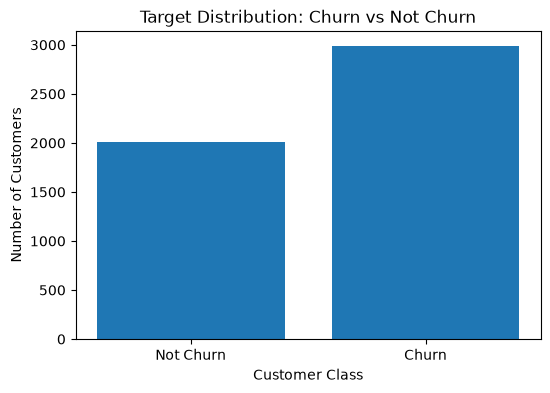

Churn percentage: 59.82 %


In [39]:
plt.figure(figsize=(6, 4))                        # create a canvas 6x4 inches
plt.bar(["Not Churn", "Churn"], churn_counts.values)  # one bar per class, heights = counts
plt.xlabel("Customer Class")                      # label the x-axis
plt.ylabel("Number of Customers")                 # label the y-axis
plt.title("Target Distribution: Churn vs Not Churn")  # chart title
plt.show()                                        # actually display the chart

# .mean() of a 0/1 column = the fraction that are 1 = the churn rate. *100 -> percentage.
print("Churn percentage:", round(customer_df["Churn"].mean() * 100, 2), "%")

## Feature Distribution
Let us visualize a few important numeric features.

### 🔎 Cell explained: the shape of each number column

A **histogram** shows how a single number is spread out — where most values pile up and where they thin out. We loop through a few key numeric features and draw one histogram each, so you can *see* things like "most customers make very few support calls, a few make many."

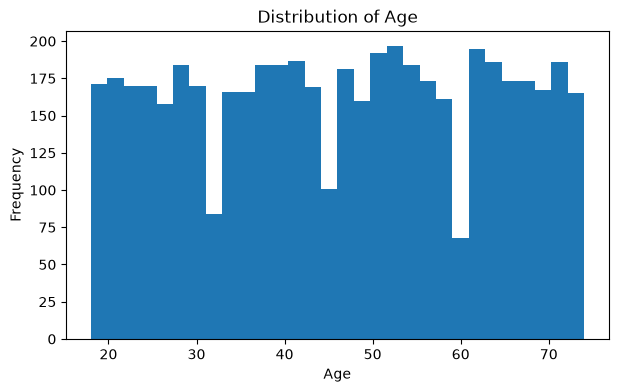

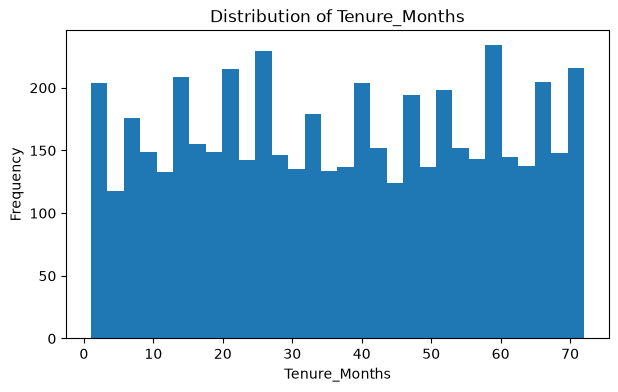

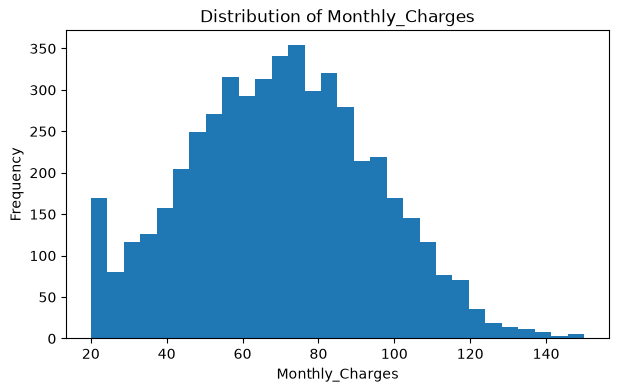

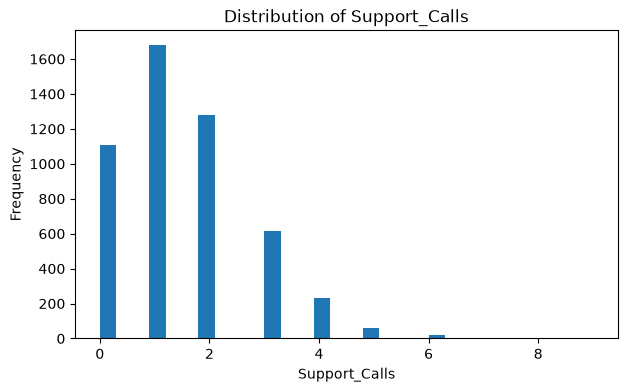

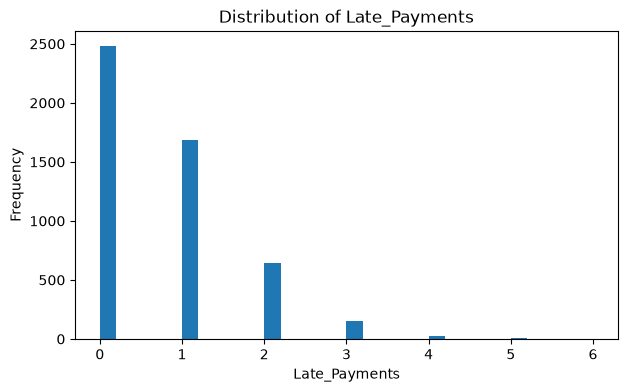

In [10]:
# A short list of the numeric features we want to visualize.
selected_numeric_features = ["Age", "Tenure_Months", "Monthly_Charges", "Support_Calls", "Late_Payments"]

# Loop = repeat the same drawing code once for each feature in the list.
for col in selected_numeric_features:
    plt.figure(figsize=(7, 4))          # fresh canvas for each chart
    plt.hist(customer_df[col], bins=30) # histogram; bins=30 = split the range into 30 bars
    plt.xlabel(col)                     # x-axis = the feature's values
    plt.ylabel("Frequency")             # y-axis = how many customers fall in each bar
    plt.title(f"Distribution of {col}") # title uses the current column name
    plt.show()                          # show this chart before moving to the next

## Relationship Between Features and Churn
We will compare average churn rate across different groups.

### 🔎 Cell explained: does contract type affect churn?

Now we connect a feature to the target. We **group** customers by their contract type and, within each group, compute the average of the Churn column — which is exactly that group's churn *rate*. This reveals whether month-to-month customers really do leave more (they should, because we designed them to).

In [11]:
# groupby("Contract_Type") = split customers into buckets by contract.
# ["Churn"].mean() = within each bucket, the average of 0/1 = that bucket's churn rate.
# sort_values(ascending=False) = list the riskiest contract type first.
contract_churn = customer_df.groupby("Contract_Type")["Churn"].mean().sort_values(ascending=False)
contract_churn

Contract_Type
Month-to-month    0.705692
One year          0.547715
Two year          0.357216
Name: Churn, dtype: float64

### 🔎 Cell explained: same finding, as a chart

The same churn-by-contract numbers, drawn as bars so the difference jumps out visually.

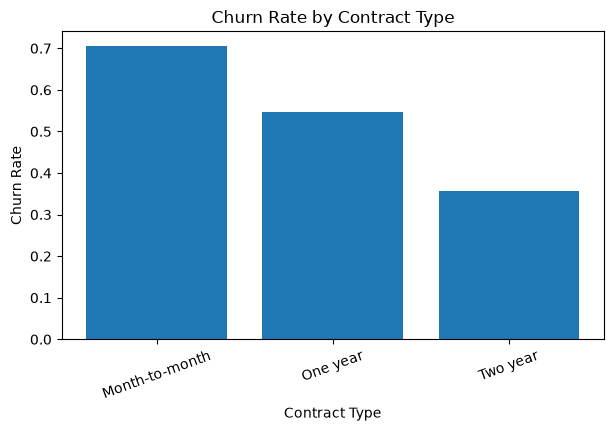

In [12]:
plt.figure(figsize=(7, 4))
plt.bar(contract_churn.index, contract_churn.values)  # x = contract names, y = churn rates
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=20)   # tilt the x labels 20 degrees so they don't overlap
plt.show()

### 🔎 Cell explained: does payment method affect churn?

Same idea as contracts, but grouping by how customers pay. We expect "Electronic check" users to churn more, because that's a pattern we baked in.

In [13]:
# Group by payment method, then the average Churn per group = churn rate per method.
payment_churn = customer_df.groupby("Payment_Method")["Churn"].mean().sort_values(ascending=False)
payment_churn

Payment_Method
Electronic check    0.643574
Bank transfer       0.574288
Mailed check        0.568273
Credit card         0.561519
Name: Churn, dtype: float64

### 🔎 Cell explained: payment-method churn, as a chart

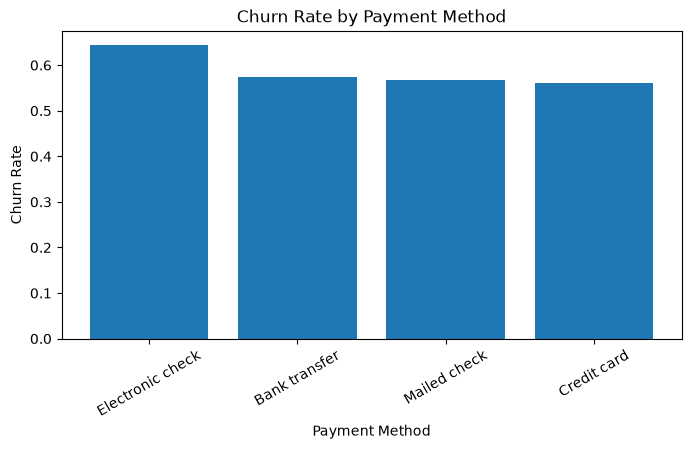

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(payment_churn.index, payment_churn.values)  # x = payment methods, y = churn rates
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=30)   # tilt labels so longer names still fit
plt.show()

### 🔎 Cell explained: comparing the two groups' averages

Here we flip the grouping: split customers into "stayed" vs "churned", then compare their *average* age, tenure, charges, support calls, and late payments. If churners average much shorter tenure and more support calls, you can literally see the story of *why* people leave — great intuition before modeling.

In [15]:
# Group by the target (0 vs 1), then show the average of each listed numeric feature.
# Reading across the two rows tells you how stayers and leavers differ on average.
customer_df.groupby("Churn")[["Age", "Tenure_Months", "Monthly_Charges", "Support_Calls", "Late_Payments"]].mean()

,Age,Tenure_Months,Monthly_Charges,Support_Calls,Late_Payments
Churn,,,,,
0,45.498756,43.835241,61.435625,1.353410,0.588352
1,46.585089,32.201270,76.046235,1.590438,0.796055


## Student Task 2
Based on EDA, answer:

1. Which contract type has the highest churn rate?
2. Which payment method has the highest churn rate?
3. Do customers with more support calls churn more?
4. Do customers with shorter tenure churn more?
5. Is the dataset heavily imbalanced?

# Module 4: Feature Engineering and Preprocessing

Most machine learning models cannot directly understand text categories such as:

```text
Month-to-month
Fiber optic
Electronic check
```

So we need preprocessing.

| Column Type | Technique |
|---|---|
| Numeric columns | StandardScaler |
| Categorical columns | OneHotEncoder |
| ID column | Drop |
| Target column | Keep separately |

### 🔎 Cell explained: separating the questions from the answer

Every supervised project splits the data into two parts:
- **X** = the *features* — everything the model is allowed to look at (the "questions").
- **y** = the *target* — the single answer column, Churn (the "answers").

We drop **Customer_ID** because it's just a name tag with no predictive meaning — letting the model see it would be like predicting exam results from students' roll numbers. And we drop **Churn** from X so the model can't "cheat" by peeking at the answer it's supposed to guess.

In [16]:
target = "Churn"   # the name of the answer column

# X = the table WITHOUT the answer and WITHOUT the useless ID.
#   axis is handled by "columns="; this returns everything else as the features.
X = customer_df.drop(columns=[target, "Customer_ID"])

# y = just the answer column, on its own.
y = customer_df[target]

print("Feature shape:", X.shape)  # (rows, number-of-features)
print("Target shape:", y.shape)   # (rows,) -> a single column

Feature shape: (5000, 10)
Target shape: (5000,)


### 🔎 Cell explained: which columns are numbers, which are text?

Numbers and text need *different* preprocessing (scaling vs encoding). So we ask pandas to automatically sort the feature columns into two lists based on their data type. This saves us from typing the column names by hand and keeps things tidy.

In [17]:
# select_dtypes(include=[...]) = keep only columns of the given types.
# int64/float64 are number types -> these are our numeric features.
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# object/category are text types -> these are our categorical (text) features.
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Monthly_Charges', 'Total_Charges', 'Data_Usage_GB']
Categorical features: ['Contract_Type', 'Internet_Service', 'Payment_Method']


## Train-Test Split

We split data into:

- **Training data:** used to train the model
- **Testing data:** used to check model performance on unseen data

We use `stratify=y` to maintain similar churn percentage in both training and testing sets.

### 🔎 Cell explained: the "final exam" split

We hide 20% of the data in a vault (**the test set**) and let the model learn only from the other 80% (**the training set**). Later we grade the model *only* on the vaulted data it has never seen. This is the only honest way to know if it will work on real future customers, instead of just memorizing.

- `test_size=0.20` → 20% goes to the vault.
- `random_state=42` → same split every run (reproducible).
- `stratify=y` → keep the churn percentage the *same* in both piles, so the exam is representative and fair.

In [18]:
# Split X and y into training and testing halves, all at once.
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # the features
    y,                 # the answers
    test_size=0.20,    # 20% -> test (the locked vault), 80% -> train
    random_state=42,   # fixed seed so the split is identical every run
    stratify=y         # keep the same churn ratio in both train and test
)

print("Training rows:", X_train.shape[0])  # ~4000
print("Testing rows:", X_test.shape[0])    # ~1000
# Confirm stratify worked: both churn rates should be nearly identical.
print("Training churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")

Training rows: 4000
Testing rows: 1000
Training churn rate: 59.82 %
Testing churn rate: 59.8 %


### 🔎 Cell explained: building the "translation assembly line"

Models only understand clean numbers, so we build an automatic translator:
- **StandardScaler** rescales number columns so a big-numbered column (like Total_Charges in the thousands) can't bully a small-numbered one (like Support_Calls) just by size. It puts them on a fair, common scale.
- **OneHotEncoder** turns each text category into simple yes/no (1/0) columns, without inventing a fake ranking.

`ColumnTransformer` is the traffic cop that sends number columns to the scaler and text columns to the encoder. Wrapping this once means every model later gets *identical, correct* preprocessing — and new customers get translated the exact same way automatically.

In [19]:
# Step for NUMBER columns: just standard-scale them.
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())   # center around 0 and put on a comparable scale
])

# Step for TEXT columns: one-hot encode them.
categorical_transformer = Pipeline(steps=[
    # handle_unknown="ignore" = if a NEW category shows up later that we never trained on,
    # don't crash -- just encode it as all zeros. Safer for real production data.
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# The traffic cop: route each group of columns to the right transformer.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),      # numbers -> scaler
        ("cat", categorical_transformer, categorical_features)  # text -> one-hot
    ]
)

print("Preprocessing pipeline created")

Preprocessing pipeline created


## Student Task 3
Answer:

1. Why did we drop `Customer_ID`?
2. Why do we use `OneHotEncoder` for categorical columns?
3. Why do we use `StandardScaler` for numeric columns?
4. Why did we use `stratify=y` in train-test split?
5. Why is a pipeline useful in real ML projects?

# Module 5: Model Building

We will train multiple classification models:

1. Dummy Classifier baseline
2. Logistic Regression
3. Decision Tree Classifier
4. Random Forest Classifier

The goal is to compare models and select the best one.

## Evaluation Function

We will create a function to evaluate every model consistently.

Classification metrics:

| Metric | Meaning |
|---|---|
| Accuracy | Overall correct predictions |
| Precision | Out of predicted churn customers, how many actually churned |
| Recall | Out of actual churn customers, how many we caught |
| F1-score | Balance between precision and recall |
| ROC-AUC | Ability to separate churn and not churn customers |

For churn prediction, **recall is very important** because missing a churn customer can be costly for business.

### 🔎 Cell explained: one fair scorecard for every model

To compare models fairly, we grade them all the exact same way. This reusable function takes any trained model, makes predictions on the test set, and returns the five key scores in a neat dictionary. Writing it once avoids copy-paste mistakes and keeps every model on a level playing field.

Quick reminder of the scores: **Accuracy** = overall % right; **Precision** = of those flagged churn, how many truly churned; **Recall** = of the real churners, how many we caught; **F1** = balance of precision & recall; **ROC-AUC** = how well it separates the two groups.

In [20]:
def evaluate_classification_model(model, X_test, y_test, model_name):
    """Evaluate a classification model and return key metrics."""
    # Ask the model for its yes/no predictions on the unseen test customers.
    y_pred = model.predict(X_test)

    # Some models can also output a PROBABILITY (e.g. "0.83 chance of churn").
    # ROC-AUC needs those probabilities, so we grab them if available.
    if hasattr(model, "predict_proba"):
        # predict_proba returns 2 columns [P(stay), P(churn)]; [:, 1] keeps P(churn).
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan  # "not available" for models without probabilities

    # Compare predictions (y_pred) against the true answers (y_test) for each score.
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        # zero_division=0 = if a score can't be computed, report 0 instead of crashing.
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    }

    return results  # hand back all scores as a dictionary

## 1. Baseline Model: Dummy Classifier
A baseline model gives a simple reference point.

Here, the dummy classifier predicts the most frequent class.

Any useful ML model should perform better than this baseline.

### 🔎 Cell explained: the "no-brain" baseline

Before celebrating any model, we need a floor to beat. The **Dummy Classifier** learns nothing — it just always predicts the most common answer ("most people stay, so I'll say everyone stays"). If a real model can't beat this, it's adding no value. Notice we wrap it in a Pipeline with our preprocessor, so it goes through the exact same steps as every other model.

In [21]:
# Chain preprocessing + the dummy model into one object.
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),                     # translate the data first
    ("model", DummyClassifier(strategy="most_frequent")) # then "predict" the majority class
])

dummy_model.fit(X_train, y_train)  # "train" it (it barely learns anything, by design)

# Score it with our reusable function.
dummy_results = evaluate_classification_model(
    dummy_model, X_test, y_test, "Dummy Classifier"
)

dummy_results  # show the baseline scores -- our bar to beat

{'Model': 'Dummy Classifier',
 'Accuracy': 0.598,
 'Precision': 0.598,
 'Recall': 1.0,
 'F1 Score': 0.7484355444305382,
 'ROC-AUC': 0.5}

## 2. Logistic Regression
Logistic Regression is a simple and popular classification model.

Despite the name regression, it is commonly used for classification problems.

### 🔎 Cell explained: Logistic Regression (the reliable classic)

Despite "regression" in the name, this is a **classification** model. Intuitively it finds a boundary separating likely-churn from likely-stay, and outputs a probability for each customer. It's fast, simple, and interpretable — usually the first serious model people try.

In [22]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),   # same translation step
    # max_iter=1000 = give the math solver enough attempts to settle on an answer.
    # random_state=42 = reproducible results.
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)  # learn the patterns from the training data

logistic_results = evaluate_classification_model(
    logistic_model, X_test, y_test, "Logistic Regression"
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.711,
 'Precision': 0.7456279809220986,
 'Recall': 0.7842809364548495,
 'F1 Score': 0.7644661776691116,
 'ROC-AUC': 0.7687191134627864}

## 3. Decision Tree Classifier
A Decision Tree asks question-based rules, like a flowchart.

Example:

```text
Is contract month-to-month?
Is monthly charge high?
Did the customer make support calls?
```

Then it predicts churn or not churn.

### 🔎 Cell explained: Decision Tree (the flowchart)

A decision tree learns a series of yes/no questions, like a troubleshooting flowchart ("Is the contract month-to-month? → Are support calls high? → predict churn"). It's very easy to read, but a single tree can overfit (memorize quirks). We cap it with `max_depth=6` so it can't grow endlessly and memorize noise.

In [23]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    # max_depth=6 = allow at most 6 layers of questions. Shallower = more general,
    # less likely to memorize the training data.
    ("model", DecisionTreeClassifier(max_depth=6, random_state=42))
])

decision_tree_model.fit(X_train, y_train)

decision_tree_results = evaluate_classification_model(
    decision_tree_model, X_test, y_test, "Decision Tree"
)

decision_tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.682,
 'Precision': 0.7153846153846154,
 'Recall': 0.7775919732441472,
 'F1 Score': 0.7451923076923077,
 'ROC-AUC': 0.7259875372302367}

## 4. Random Forest Classifier
Random Forest creates many decision trees and combines their predictions.

Layman meaning:

```text
Decision Tree = one expert
Random Forest = group of experts
```

It is usually more stable than a single decision tree.

### 🔎 Cell explained: Random Forest (a crowd of experts)

Instead of trusting one flowchart, a Random Forest builds **many** decision trees on slightly different slices of the data and lets them **vote**. It's the *wisdom of crowds*: individual mistakes cancel out, so the group is steadier and usually more accurate than any single tree. This is often the strongest model in the whole notebook.

In [24]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,   # build 150 separate trees, then let them vote
        max_depth=8,        # each tree can be up to 8 questions deep
        random_state=42,    # reproducible
        n_jobs=-1           # use ALL CPU cores to train faster (-1 = all available)
    ))
])

random_forest_model.fit(X_train, y_train)

random_forest_results = evaluate_classification_model(
    random_forest_model, X_test, y_test, "Random Forest"
)

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.71,
 'Precision': 0.727810650887574,
 'Recall': 0.822742474916388,
 'F1 Score': 0.7723704866562009,
 'ROC-AUC': 0.7668097638895822}

# Module 6: Model Evaluation and Comparison

Now we compare all models in one table.

### 🔎 Cell explained: all models side by side

We collect every model's scorecard into one table and sort it by **F1-score** (our balanced tiebreaker). Now you can compare the dummy baseline against the three real models at a glance and see who wins.

In [25]:
# Put each model's results-dictionary into rows of one comparison table.
results_df = pd.DataFrame([
    dummy_results,
    logistic_results,
    decision_tree_results,
    random_forest_results
])

# Sort so the best F1-score sits at the top.
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest,0.710,0.727811,0.822742,0.772370,0.766810
1,Logistic Regression,0.711,0.745628,0.784281,0.764466,0.768719
0,Dummy Classifier,0.598,0.598000,1.000000,0.748436,0.500000
2,Decision Tree,0.682,0.715385,0.777592,0.745192,0.725988


## Confusion Matrix

A confusion matrix shows where the model is correct and where it is wrong.

For churn prediction:

| Term | Meaning |
|---|---|
| True Negative | Correctly predicted not churn |
| True Positive | Correctly predicted churn |
| False Positive | Predicted churn but customer did not churn |
| False Negative | Predicted not churn but customer actually churned |

For churn business problems, **False Negative is risky** because the company misses a customer who is likely to leave.

### 🔎 Cell explained: the confusion matrix (where it's right vs wrong)

This 2x2 grid breaks predictions into four boxes:
- **True Negative**: said stay, was stay ✅
- **True Positive**: said churn, was churn ✅
- **False Positive**: said churn, but stayed (a false alarm) ❌
- **False Negative**: said stay, but actually churned (missed them!) ❌

For churn, the **False Negatives** are the scary box — those are customers who quietly walked out while the model said "all good." Seeing the real counts tells you *what kind* of mistakes your model makes, not just how many.

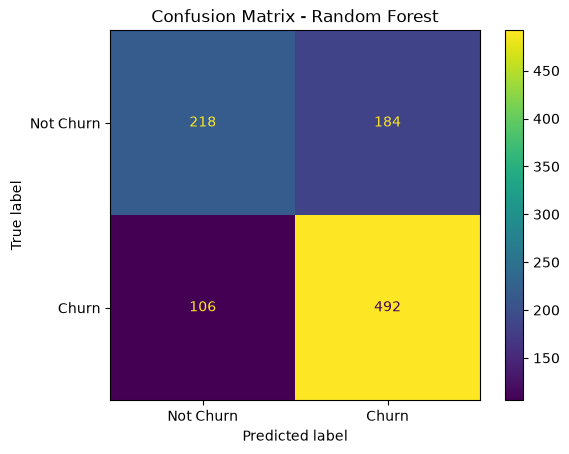

In [26]:
# Get the Random Forest's yes/no predictions on the test set.
rf_pred = random_forest_model.predict(X_test)

# Build the 2x2 grid comparing true answers vs predictions.
cm = confusion_matrix(y_test, rf_pred)

# Wrap it in a display helper with friendly labels, and draw it.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(values_format="d")   # "d" = show plain whole numbers (not 1e+03 etc.)
plt.title("Confusion Matrix - Random Forest")
plt.show()

### 🔎 Cell explained: the full scorecard in one table

`classification_report` prints precision, recall, and F1 **for each class separately** (Not Churn and Churn), plus how many of each were in the test set. Look especially at the "Churn" row — that's the group the business actually cares about catching.

In [27]:
# Prints a tidy table of precision/recall/F1 for BOTH classes.
# target_names just replaces "0"/"1" with readable labels.
print(classification_report(y_test, rf_pred, target_names=["Not Churn", "Churn"]))

              precision    recall  f1-score   support

   Not Churn       0.67      0.54      0.60       402
       Churn       0.73      0.82      0.77       598

    accuracy                           0.71      1000
   macro avg       0.70      0.68      0.69      1000
weighted avg       0.71      0.71      0.70      1000



## ROC Curve
ROC curve helps us understand how well the model separates churn from not churn.

Higher ROC-AUC means better separation ability.

### 🔎 Cell explained: the ROC curve (separation power)

The ROC curve shows how well the model separates churners from stayers across *all* possible decision cutoffs, not just the default. The more the curve bows toward the top-left corner, the better. The area under it (**AUC**) is a single score: 1.0 = perfect separation, 0.5 = no better than a coin flip.

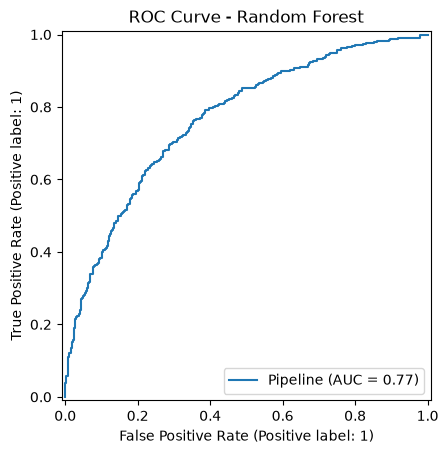

In [28]:
# Draw the ROC curve straight from the trained model + test data.
RocCurveDisplay.from_estimator(random_forest_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

## Student Task 4
Answer:

1. Which model has the highest accuracy?
2. Which model has the highest recall?
3. Which model has the highest F1-score?
4. For churn prediction, why can recall be more important than accuracy?
5. Which model would you choose and why?

# Cross Validation

Normal train-test split tests the model once.

Cross-validation tests the model multiple times on different parts of the data.

This gives a more reliable performance estimate.

### 🔎 Cell explained: cross-validation (test 5 times, not once)

A single train/test split is just one exam — the model might have gotten a lucky or unlucky test set. **Cross-validation** slices the data into 5 parts and runs the whole train-and-test cycle 5 times, each time testing on a different part. Averaging the 5 scores gives a much more trustworthy estimate, and the standard deviation tells you how much the score wobbles (small wobble = reliable).

In [29]:
# cv=5 -> split into 5 folds; train on 4, test on 1, repeat 5 times.
# scoring="f1" -> grade each round with the F1-score.
# n_jobs=-1 -> use all CPU cores. Runs on the FULL X, y (it does its own splitting).
cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Cross-validation F1 scores:", cv_scores)          # the 5 individual scores
print("Average CV F1 score:", round(cv_scores.mean(), 4)) # the trustworthy average
print("Standard deviation:", round(cv_scores.std(), 4))   # how much they wobble

Cross-validation F1 scores: [0.78455598 0.7788162  0.7733119  0.77886792 0.79389313]
Average CV F1 score: 0.7819
Standard deviation: 0.007


# Module 7: Hyperparameter Tuning

Hyperparameter tuning means finding the best settings for a model.

For Random Forest, we can tune:

| Hyperparameter | Meaning |
|---|---|
| n_estimators | Number of trees |
| max_depth | Maximum depth of each tree |
| min_samples_split | Minimum samples needed to split a node |
| min_samples_leaf | Minimum samples needed in a final leaf |

We will use `GridSearchCV`.

### 🔎 Cell explained: auto-tuning the model's settings

Every model has **knobs** you set *before* training (how many trees, how deep, etc.) — these are **hyperparameters**. Good settings can meaningfully boost performance. Rather than guessing, **GridSearchCV** tries every combination on our menu, cross-validates each, and reports the winner.

Note the `model__` prefix on each setting — that's how we tell the pipeline "this knob belongs to the *model* step, not the preprocessing step."

In [30]:
# The "menu" of settings to try. GridSearch will test EVERY combination of these.
# "model__" means: apply this to the "model" step inside our pipeline.
param_grid = {
    "model__n_estimators": [100, 150],       # try 100 trees, and 150 trees
    "model__max_depth": [5, 8, 12],          # try 3 different tree depths
    "model__min_samples_split": [2, 5],      # min samples needed to split a branch
    "model__min_samples_leaf": [1, 2]        # min samples allowed in a final leaf
}
# Total combos = 2 * 3 * 2 * 2 = 24 different models to test.

grid_search = GridSearchCV(
    estimator=random_forest_model,  # the pipeline we're tuning
    param_grid=param_grid,          # the menu above
    cv=3,                           # 3-fold cross-validation for each combo (kept small for speed)
    scoring="f1",                   # pick the combo with the best F1
    n_jobs=-1,                      # use all CPU cores
    verbose=1                       # print progress while it runs
)

grid_search.fit(X_train, y_train)  # do the whole search on the training data

print("Best parameters:", grid_search.best_params_)             # the winning knob settings
print("Best CV F1 score:", round(grid_search.best_score_, 4))   # its cross-validated score

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 150}
Best CV F1 score: 0.785


### 🔎 Cell explained: grading the tuned model

GridSearch already refit the best settings on all the training data. Here we pull out that best model and score it on the untouched **test set** with our same scorecard, so we can compare it fairly against the earlier models.

In [31]:
# best_estimator_ = the fully-trained pipeline using the winning settings.
best_model = grid_search.best_estimator_

# Score the tuned model on the test set with our reusable function.
tuned_results = evaluate_classification_model(
    best_model,
    X_test,
    y_test,
    "Tuned Random Forest"
)

tuned_results

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.707,
 'Precision': 0.7115117891816921,
 'Recall': 0.8578595317725752,
 'F1 Score': 0.7778620166793025,
 'ROC-AUC': 0.7587605451005841}

### 🔎 Cell explained: adding the tuned model to the leaderboard

We append the tuned model's row to the earlier comparison table and re-sort by F1, giving one final leaderboard of every model we built.

In [32]:
# concat = stack the old results table and the new tuned-model row together.
final_results_df = pd.concat([
    results_df,
    pd.DataFrame([tuned_results])
], ignore_index=True)   # ignore_index = renumber the rows cleanly 0,1,2,...

# Sort the final leaderboard by F1-score, best first.
final_results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Tuned Random Forest,0.707,0.711512,0.857860,0.777862,0.758761
3,Random Forest,0.710,0.727811,0.822742,0.772370,0.766810
1,Logistic Regression,0.711,0.745628,0.784281,0.764466,0.768719
0,Dummy Classifier,0.598,0.598000,1.000000,0.748436,0.500000
2,Decision Tree,0.682,0.715385,0.777592,0.745192,0.725988


# Feature Importance

Feature importance tells us which features were most useful for prediction.

This works well with tree-based models like Random Forest.

### 🔎 Cell explained: which features mattered most?

Tree models can report how much each feature contributed to their decisions. But there's a catch: after one-hot encoding, "Contract_Type" became several 0/1 columns, so we must rebuild the *post-encoding* feature names to line them up with the importance scores. Then we sort to see the top drivers of churn — this is where we check whether the model rediscovered the patterns we planted back in the data-creation cell.

In [33]:
# Reach inside the tuned pipeline and grab its two parts by name.
preprocessor_fitted = best_model.named_steps["preprocessor"]  # the translator
model_fitted = best_model.named_steps["model"]                # the trained forest

# The numeric feature names stay the same after scaling.
num_features = numeric_features

# The text features got expanded by one-hot encoding, so ask the encoder
# for the NEW column names it created (e.g. "Contract_Type_Two year").
cat_encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

# Full list of feature names, in the same order the model sees them.
all_feature_names = num_features + cat_features

# Pair each feature name with its importance score, then sort biggest-first.
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": model_fitted.feature_importances_   # how much each feature was used
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)  # show the 10 most influential features

,Feature,Importance
0,Monthly_Charges,0.370250
5,Contract_Type_Two year,0.169090
1,Total_Charges,0.164721
3,Contract_Type_Month-to-month,0.159271
2,Data_Usage_GB,0.049741
4,Contract_Type_One year,0.031025
11,Payment_Method_Electronic check,0.018455
7,Internet_Service_Fiber optic,0.009184
8,Internet_Service_No,0.006333
12,Payment_Method_Mailed check,0.006165


### 🔎 Cell explained: top drivers of churn, as a chart

A horizontal bar chart of the 10 most important features. This is the kind of visual you'd show a manager: "these are the factors most linked to customers leaving."

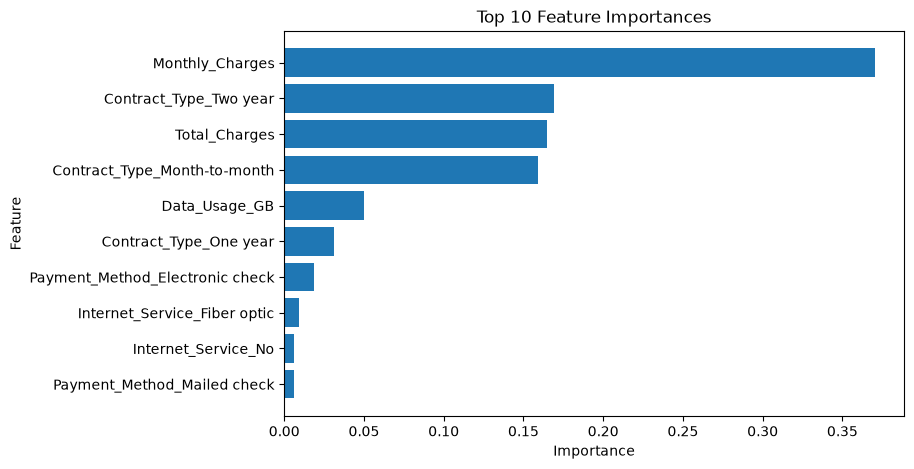

In [34]:
# Take the top 10, then re-sort ascending so the biggest bar ends up on top in barh.
top_features = importance_df.head(10).sort_values(by="Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])  # barh = horizontal bars
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.show()

# Save the Final Model

After selecting the best model, save it using `joblib`.

This saved model can later be used in a Streamlit app, Flask API, FastAPI app, or production system.

### 🔎 Cell explained: freezing the finished model into a file

Training takes time; you don't want to redo it constantly. `joblib.dump` saves the entire trained pipeline (preprocessing + model together) into a single `.pkl` file. Later, a website or app can load this file instantly and start scoring customers — no retraining. This is the bridge from "notebook experiment" to "real product."

In [35]:
# Choose a filename for the saved model.
model_filename = "customer_churn_classification_model.pkl"

# Save the ENTIRE pipeline (translator + trained forest) to disk in one file.
joblib.dump(best_model, model_filename)

print("Model saved as:", model_filename)

Model saved as: customer_churn_classification_model.pkl


### 🔎 Cell explained: downloading the model (Colab only)

If you're running in Google Colab, this pops up a download so you can save the `.pkl` to your computer. On other setups it just prints a friendly note instead of crashing — that's what the `try/except` is for.

In [36]:
# try/except = "attempt this; if it fails, do the backup plan instead of crashing."
try:
    from google.colab import files   # this import only works inside Google Colab
    files.download(model_filename)    # trigger a browser download of the saved model
except Exception as e:
    # If we're NOT in Colab, the import fails and we land here.
    print("Download works only in Google Colab.")

Download works only in Google Colab.


# Make Prediction for a New Customer

Now let us predict whether a new customer will churn.

### 🔎 Cell explained: scoring a brand-new customer (the payoff)

Everything comes together here. We describe one new customer (young, only 6 months in, high charges, month-to-month, several support calls — a textbook flight risk) as a one-row table with the **same columns** the model was trained on. Because we saved the whole pipeline, it automatically scales and encodes this raw input, then returns both a verdict *and* a churn probability. The probability is what makes it actionable — the retention team can prioritize the 90%-risk customers over the 55%-risk ones.

In [37]:
# Build a one-row table for the new customer.
# IMPORTANT: same column names as training, and NO Customer_ID / NO Churn.
new_customer = pd.DataFrame({
    "Age": [35],
    "Tenure_Months": [6],           # only 6 months in -> risky
    "Monthly_Charges": [110.0],     # a high bill -> risky
    "Total_Charges": [660.0],
    "Contract_Type": ["Month-to-month"],   # riskiest contract
    "Internet_Service": ["Fiber optic"],
    "Payment_Method": ["Electronic check"],# higher-churn payment type
    "Support_Calls": [4],           # several calls -> frustration -> risky
    "Data_Usage_GB": [75.0],
    "Late_Payments": [2]            # late payments -> risky
})

# The pipeline auto-scales & auto-encodes this row, then predicts.
prediction = best_model.predict(new_customer)[0]              # 0 = stay, 1 = churn
probability = best_model.predict_proba(new_customer)[0][1]    # the P(churn) score

# Turn the raw 0/1 into a readable word, and show the probability as a percentage.
print("Prediction:", "Churn" if prediction == 1 else "Not Churn")
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: Churn
Churn Probability: 88.14 %


## Business Interpretation

If the model predicts a high churn probability, the retention team can take action:

- Offer discount
- Call the customer
- Resolve service issue
- Offer better plan
- Provide loyalty reward

Machine learning helps the business act before the customer leaves.

# Module 8: Final Assignment

## Assignment Problem
Improve the churn prediction model by trying the following:

1. Add a new feature called `High_Value_Customer`.
   - If monthly charges are greater than 90, mark as 1, else 0.
2. Train Logistic Regression and Random Forest again.
3. Compare old and new model performance.
4. Tune Random Forest with a larger parameter grid.
5. Try changing the classification threshold from 0.5 to 0.4.
6. Observe whether recall improves.
7. Write a short business recommendation.

## Submission Requirements
Students should submit:

1. Completed Colab notebook
2. Model comparison table
3. Confusion matrix
4. ROC curve
5. Feature importance chart
6. Final business interpretation

# Viva / Interview Questions

1. What is supervised learning?
2. What is classification?
3. Why is churn prediction a classification problem?
4. What is the difference between binary and multiclass classification?
5. What is accuracy?
6. What is precision?
7. What is recall?
8. What is F1-score?
9. What is confusion matrix?
10. Why can accuracy be misleading in imbalanced datasets?
11. What is ROC-AUC?
12. What is cross-validation?
13. What is hyperparameter tuning?
14. Why is Random Forest usually more stable than Decision Tree?
15. How can this model help a telecom business?

# Final Summary

In this 4-hour hands-on project, we built an end-to-end supervised learning classification solution.

We followed this full ML lifecycle:

```text
Problem understanding
Dataset creation
EDA
Preprocessing
Train-test split
Model building
Model evaluation
Cross-validation
Hyperparameter tuning
Feature importance
Model saving
New prediction
Business interpretation
```

This is the same flow used in real-world classification projects.